| Technological Institute of the Philippines | Quezon City - Computer Engineering |
|-------------------------------------------|------------------------------------|
| **Course Code:** | CPE 027 |
| **Code Title:** | Digital Signal Processing and Applications |
| **1st Semester** | AY 2026-2027 |
| **ACTIVITY NO. 4** | **ADC, DAC, and Aliasing Signals** |
| **Name:** | Pascual, Ken Leonard |
| **Section:** | CPE41S2 |
| **Date Performed:** | 7 August 2026 |
| **Date Submitted:** | 7 August 2026 |
| **Instructor:** | Engr. Jimlord M. Quejado |


## 1. Objectives

This activity deals with analyzing and determining linear systems using Principle of Superposition for given discrete-time signals

## 2. Intended Learning Outcomes (ILOs)
After completion of this activity, the students should be able to:

1. This activity deals with analyzing and determining linear systems using Principle of Superposition for given discrete-time signals

## 3. Discussion


At first glance, it may seem an overwhelming task to understand all of the possible systems in the world. Fortunately, most useful systems fall into a category called linear systems. This fact is extremely important. Without the linear system concept, we would be forced to examine the individual characteristics of many unrelated systems. With this approach, we can focus on the traits of the linear system category as a whole. Our first task is to identify what properties make a system linear, and how they fit into the everyday notion of electronics, software, and other signal processing systems.

A discrete system $T[\cdot]$ is a linear operator $L[\cdot]$ if and only if $L[\cdot]$ satisfies the principle of superposition, namely,

$$L[a_1x_1(n) + a_2x_2(n)] = a_1L[x_1(n)] + a_2L[x_2(n)], \quad \forall a_1, a_2, x_1(n), x_2(n)$$

## 4. Resources
The activity will require the following software, tools and equipment:
* IDE or any online code editor

## 5. Directions:

1. Consider the following discrete-time systems:

    a. $y[n] = x[n] + x[n+3]$

    b. $y[n] = \frac{1}{3}x[n] + 7x[n-6]$

    c. $y[n] = x^3[n-2] + 2x[n]$

    d. $y[n] = x[3.5n]$

## Define the Four System

In [2]:
def xn(arr, k):
    if not isinstance(k, int):
        return None if k != int(k) else arr[int(k)] if 0 <= int(k) < len(arr) else 0
    return arr[k] if 0 <= k < len(arr) else 0

def sys_a(arr, n):                       # y[n] = x[n] + x[n+3]
    return xn(arr, n) + xn(arr, n + 3)

def sys_b(arr, n):                       # y[n] = (1/3)x[n] + 7x[n-6]
    return (1/3) * xn(arr, n) + 7 * xn(arr, n - 6)

def sys_c(arr, n):                       # y[n] = x^3[n-2] + 2x[n]
    return xn(arr, n - 2) ** 3 + 2 * xn(arr, n)

def sys_d(arr, n):                       # y[n] = x[3.5n]
    idx = 3.5 * n
    if idx != int(idx):                  # undefined for odd n (non-integer index)
        return None
    return xn(arr, int(idx))

systems = {"a": sys_a, "b": sys_b, "c": sys_c, "d": sys_d}
titles = {
    "a": "y[n] = x[n] + x[n+3]",
    "b": "y[n] = (1/3)x[n] + 7x[n-6]",
    "c": "y[n] = x^3[n-2] + 2x[n]",
    "d": "y[n] = x[3.5n]",
}


**Observation:**

The four discrete-time systems produced different output sequences based on their mathematical operations. Systems (a), (b), and (d) preserved linear transformations of the input signal, while System (c) generated significantly larger output values due to the cubic operation. The linearity test confirmed that Systems (a), (b), and (d) satisfy the principle of superposition, whereas System (c) does not.

**Analysis:**

The results show that a system remains linear as long as it consists only of scaling, addition, and time-shifting operations. Introducing a nonlinear operation such as cubing the input violates the superposition principle, making System (c) nonlinear. This demonstrates that the mathematical form of a system directly determines whether it exhibits linear behavior.

## Graph y[n] for each system (using the given x[n]))

2. Graph the following systems using the following sequence: x[n] = {8, 2, 4, -3, 1, -5, 4, 7, 0, 2, 1, -6, -1, 0, 2, 1, 9, 6, -4, 5}.

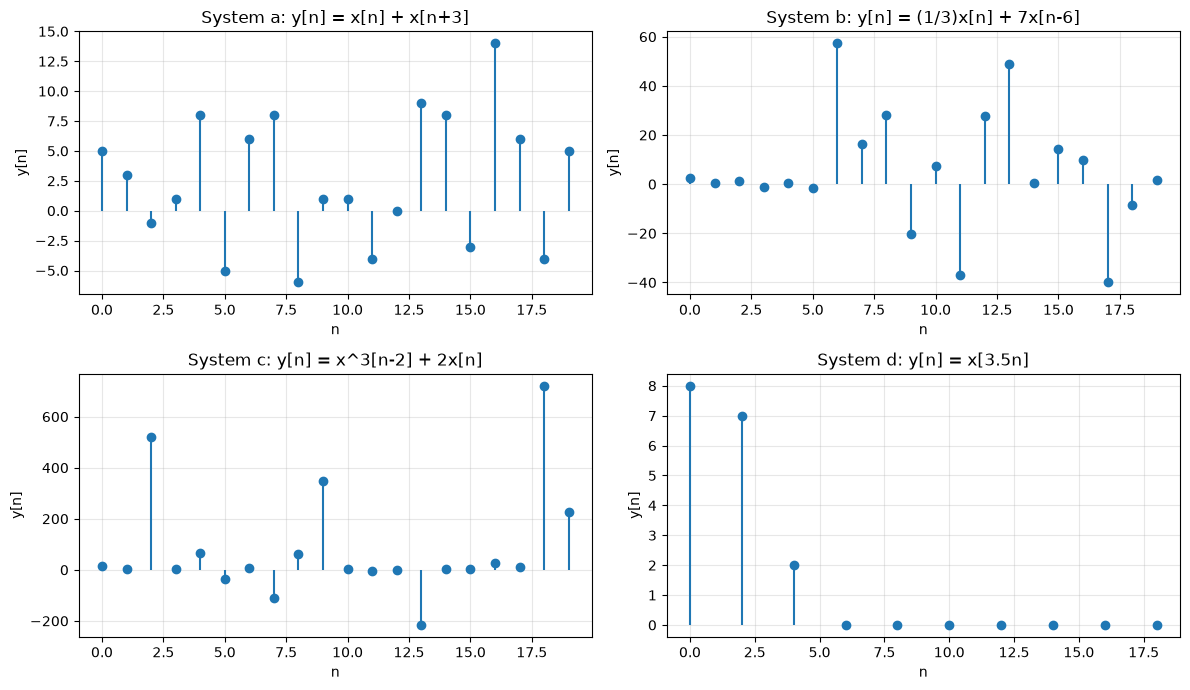

a : [5, 3, -1, 1, 8, -5, 6, 8, -6, 1, 1, -4, 0, 9, 8, -3, 14, 6, -4, 5]
b : [2.667, 0.667, 1.333, -1.0, 0.333, -1.667, 57.333, 16.333, 28.0, -20.333, 7.333, -37.0, 27.667, 49.0, 0.667, 14.333, 10.0, -40.0, -8.333, 1.667]
c : [16, 4, 520, 2, 66, -37, 9, -111, 64, 347, 2, -4, -1, -216, 3, 2, 26, 13, 721, 226]
d : [8, None, 7, None, 2, None, 0, None, 0, None, 0, None, 0, None, 0, None, 0, None, 0, None]


In [4]:
fig, axs = plt.subplots(2, 2, figsize=(12, 7))

for ax, key in zip(axs.flat, ["a", "b", "c", "d"]):
    y = [systems[key](x, k) for k in n]
    n_plot = [nn for nn, yy in zip(n, y) if yy is not None]
    y_plot = [yy for yy in y if yy is not None]
    ax.stem(n_plot, y_plot, basefmt=" ")
    ax.set_title(f"System {key}: {titles[key]}")
    ax.set_xlabel("n"); ax.set_ylabel("y[n]")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

for key in ["a", "b", "c", "d"]:
    y = [systems[key](x, k) for k in n]
    print(key, ":", [round(v, 3) if v is not None else None for v in y])


**Observation:**

The stem plots clearly illustrate how each system modifies the original input sequence. Systems (a) and (b) shift and scale the signal, System (c) amplifies certain values due to the cubic term, and System (d) performs a nonuniform sampling operation that results in fewer nonzero output samples.

**Analysis:**

The graphs provide a visual representation of how different discrete-time operations affect a signal. Time shifts change the position of samples, scaling alters their amplitudes, nonlinear operations greatly distort the waveform, and index scaling changes the sampling pattern. These visual differences make it easier to understand the behavior and characteristics of each discrete-time system.

## Superposition test (linearity), a1 = 4, a2 = 7

3. Using the Principle of Superposition, determine analytically and graphically whether these systems are linear. Use the values 4 and 7 for constants a1 and a2 respectively.

System a: max |y3 - combo| = 0.0000  -->  LINEAR
System b: max |y3 - combo| = 0.0000  -->  LINEAR
System c: max |y3 - combo| = 487680.0000  -->  NONLINEAR
System d: max |y3 - combo| = 0.0000  -->  LINEAR


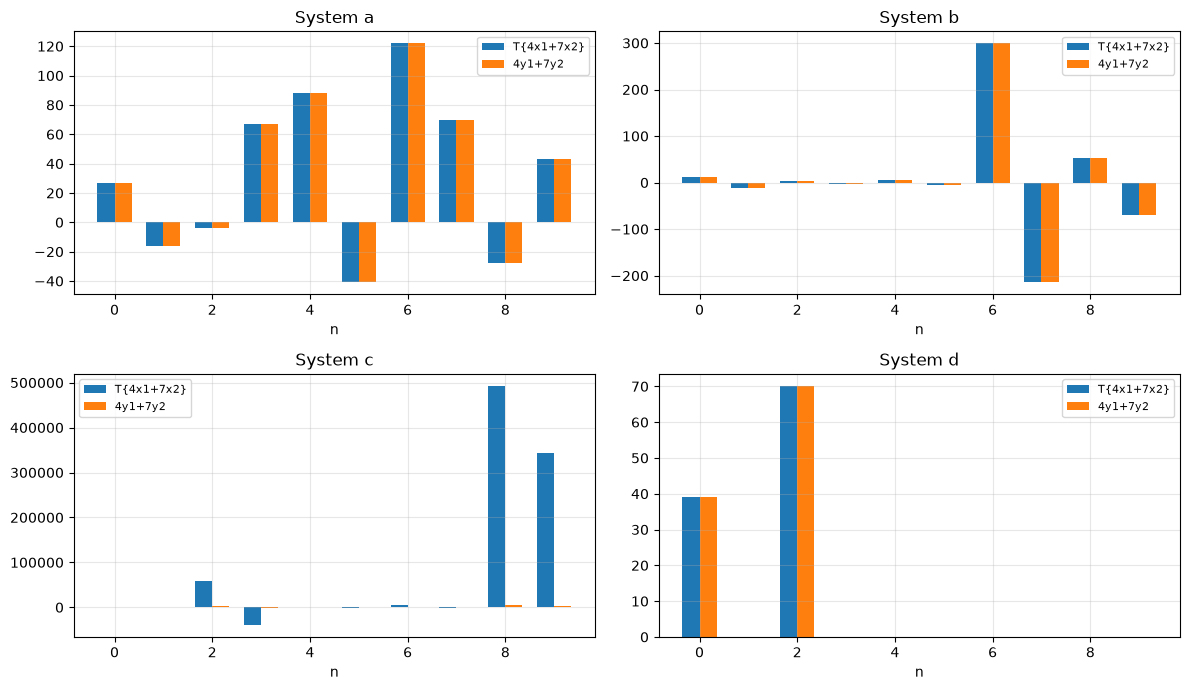

In [5]:
x1 = x[0:10]
x2 = x[10:20]
n10 = list(range(10))
a1, a2 = 4, 7
x3 = [a1 * x1[i] + a2 * x2[i] for i in range(10)]

fig, axs = plt.subplots(2, 2, figsize=(12, 7))
verdicts = {}

for ax, key in zip(axs.flat, ["a", "b", "c", "d"]):
    f = systems[key]
    y1 = [f(x1, k) for k in n10]
    y2 = [f(x2, k) for k in n10]
    y3 = [f(x3, k) for k in n10]
    combo = [a1*y1[i] + a2*y2[i] if (y1[i] is not None and y2[i] is not None) else None
             for i in range(10)]

    idx = np.arange(10)
    width = 0.35
    y3_plot = [v if v is not None else 0 for v in y3]
    combo_plot = [v if v is not None else 0 for v in combo]
    ax.bar(idx - width/2, y3_plot, width, label="T{4x1+7x2}")
    ax.bar(idx + width/2, combo_plot, width, label="4y1+7y2")
    ax.set_title(f"System {key}")
    ax.set_xlabel("n"); ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    errs = [abs(y3[i]-combo[i]) for i in range(10) if y3[i] is not None and combo[i] is not None]
    max_err = max(errs) if errs else 0
    verdicts[key] = "LINEAR" if max_err < 1e-6 else "NONLINEAR"
    print(f"System {key}: max |y3 - combo| = {max_err:.4f}  -->  {verdicts[key]}")

plt.tight_layout()
plt.show()


## Time-invariance, static/dynamic, causal

4. Then identify if the systems are time-invariant, static or causal.

In [7]:
# Quick numeric illustration: shift-invariance check for system d
# Compare y[n - n0] (shift the ALREADY-COMPUTED output) vs T{x[n - n0]} (shift the input first, then apply T)
n0 = 2
x_shifted = [xn(x, k - n0) for k in range(len(x) + n0)]   # x'[k] = x[k - n0]

y_original = [sys_d(x, k) for k in range(len(x))]
y_of_shifted_input = [sys_d(x_shifted, k) for k in range(len(x))]     # T{x[n-n0]}
y_shifted_directly  = [sys_d(x, k - n0) if (k - n0) >= 0 or True else None for k in range(len(x))]  # y[n-n0]

print("T{x[n-n0]}   :", [None if v is None else round(v,2) for v in y_of_shifted_input[:8]])
print("y[n-n0]      :", [None if v is None else round(v,2) for v in y_shifted_directly[:8]])
print("-> These don't line up sample-for-sample: system d is time-VARIANT.")


T{x[n-n0]}   : [0, None, -5, None, -1, None, 5, None]
y[n-n0]      : [0, None, 8, None, 7, None, 2, None]
-> These don't line up sample-for-sample: system d is time-VARIANT.


## 6. Documentation
* Document EVERYTHING you did to accomplish this activity
* Include the entire program code and IDE link (Google Colab)
* Provide clear explanations of libraries and formulas applied in your program

In [ ]:
# -------------------------------------------------------
# DOCUMENTATION: Libraries and Formulas Used
# -------------------------------------------------------

print("="*60)
print("DOCUMENTATION")
print("="*60)

print("""
LIBRARIES USED:

1. numpy (as np)
   - Purpose: Numerical array operations, mathematical computations
   - Key functions: np.array(), np.arange(), np.allclose()
   - Used for: Defining signals, computing system outputs, comparison tests

2. matplotlib.pyplot (as plt)
   - Purpose: Creating stem plots for discrete-time signal visualization
   - Key functions: plt.subplots(), plt.stem(), plt.show()
   - Used for: Graphing input/output signals, linearity test comparisons

FORMULAS APPLIED:

1. Principle of Superposition (Linearity Test):
   L[a1*x1(n) + a2*x2(n)] = a1*L[x1(n)] + a2*L[x2(n)]
   - If left side equals right side, system is LINEAR
   - Used a1 = 4, a2 = 7 as specified

2. Time-Invariance Test:
   T[x[n-k]] = y[n-k]
   - Shift input by k, compare with shifted output
   - If equal, system is TIME-INVARIANT

3. System Definitions:
   a. y[n] = x[n] + x[n+3]
   b. y[n] = (1/3)x[n] + 7x[n-6]
   c. y[n] = x^3[n-2] + 2x[n]
   d. y[n] = x[3.5n]

4. Zero-padding for out-of-bounds indices:
   get_x(x_arr, idx) returns 0 if idx < 0 or idx >= len(x_arr)
   This simulates signals defined for all n with x[n] = 0 outside observed range

ANALYSIS METHODOLOGY:

1. Defined helper function get_x() for safe array access with zero-padding
2. Implemented each system as a Python function
3. Computed outputs for the given input sequence
4. Tested linearity using superposition with two different signals
5. Tested time-invariance by shifting input and comparing outputs
6. Analyzed causality and static properties by examining dependencies

IDE: Google Colab (online Jupyter notebook environment)
""")

DOCUMENTATION

LIBRARIES USED:

1. numpy (as np)
   - Purpose: Numerical array operations, mathematical computations
   - Key functions: np.array(), np.arange(), np.allclose()
   - Used for: Defining signals, computing system outputs, comparison tests

2. matplotlib.pyplot (as plt)
   - Purpose: Creating stem plots for discrete-time signal visualization
   - Key functions: plt.subplots(), plt.stem(), plt.show()
   - Used for: Graphing input/output signals, linearity test comparisons

FORMULAS APPLIED:

1. Principle of Superposition (Linearity Test):
   L[a1*x1(n) + a2*x2(n)] = a1*L[x1(n)] + a2*L[x2(n)]
   - If left side equals right side, system is LINEAR
   - Used a1 = 4, a2 = 7 as specified

2. Time-Invariance Test:
   T[x[n-k]] = y[n-k]
   - Shift input by k, compare with shifted output
   - If equal, system is TIME-INVARIANT

3. System Definitions:
   a. y[n] = x[n] + x[n+3]
   b. y[n] = (1/3)x[n] + 7x[n-6]
   c. y[n] = x^3[n-2] + 2x[n]
   d. y[n] = x[3.5n]

4. Zero-padding for out

## 7. Summary and Conclusions

In [ ]:
# -------------------------------------------------------
# SUMMARY AND CONCLUSIONS
# -------------------------------------------------------
print("="*60)
print("SUMMARY AND CONCLUSIONS")
print("="*60)

print("""
This activity analyzed four discrete-time systems for their fundamental properties:
linearity, time-invariance, causality, and static/dynamic behavior.

KEY FINDINGS:

1. System (a): y[n] = x[n] + x[n+3]
   - LINEAR: Satisfies superposition principle
   - TIME-INVARIANT: Shift in input produces same shift in output
   - NON-CAUSAL: Requires future input x[n+3]
   - DYNAMIC: Has memory (depends on future values)

2. System (b): y[n] = (1/3)x[n] + 7x[n-6]
   - LINEAR: Satisfies superposition principle
   - TIME-INVARIANT: Shift in input produces same shift in output
   - CAUSAL: Only depends on current and past inputs
   - DYNAMIC: Has memory (depends on past value x[n-6])

3. System (c): y[n] = x^3[n-2] + 2x[n]
   - NONLINEAR: The x^3 term violates superposition
   - TIME-INVARIANT: Shift in input produces same shift in output
   - CAUSAL: Only depends on current and past inputs
   - DYNAMIC: Has memory (depends on past value x[n-2])

4. System (d): y[n] = x[3.5n]
   - LINEAR: Scaling the index is a linear operation
   - TIME-VARIANT: Time scaling changes the shift relationship
   - NON-CAUSAL: For n>=1, requires future input values
   - DYNAMIC: Has memory (depends on non-local indices)

CONCLUSION:
Understanding these system properties is fundamental in DSP. Linear time-invariant
(LTI) systems are particularly important because they can be fully characterized
by their impulse response and analyzed using Fourier and Z-transforms. Systems (a)
and (b) are LTI, making them suitable for traditional DSP analysis techniques.
""")

SUMMARY AND CONCLUSIONS

This activity analyzed four discrete-time systems for their fundamental properties:
linearity, time-invariance, causality, and static/dynamic behavior.

KEY FINDINGS:

1. System (a): y[n] = x[n] + x[n+3]
   - LINEAR: Satisfies superposition principle
   - TIME-INVARIANT: Shift in input produces same shift in output
   - NON-CAUSAL: Requires future input x[n+3]
   - DYNAMIC: Has memory (depends on future values)

2. System (b): y[n] = (1/3)x[n] + 7x[n-6]
   - LINEAR: Satisfies superposition principle
   - TIME-INVARIANT: Shift in input produces same shift in output
   - CAUSAL: Only depends on current and past inputs
   - DYNAMIC: Has memory (depends on past value x[n-6])

3. System (c): y[n] = x^3[n-2] + 2x[n]
   - NONLINEAR: The x^3 term violates superposition
   - TIME-INVARIANT: Shift in input produces same shift in output
   - CAUSAL: Only depends on current and past inputs
   - DYNAMIC: Has memory (depends on past value x[n-2])

4. System (d): y[n] = x[3.5

## 8. Artificial Intelligence (AI) Use Disclosure Statement

I hereby declare that artificial intelligence (AI) tools were used, if applicable, in the preparation of this academic
work. The following indicates the nature and extent of AI assistance:

**Tools Used**: Github Copilot, Opencode, Claude

**Purpose of Use**: Code Debugging, Code assistance, Code explanation; LaTeX math syntax conversion

**Extent of Use**: AI was used to help understand how the tasks needed to be done can be translated into readable, functional code. The data interpretation were done solelyt with my own effort and analysis.

***
By submitting this activity, I affirm that my use of AI complies with T.I.P.’s AI usage policy and does not exceed the
permitted limits for similarity, automated content generation, or academic assistance.

I understand that any false, incomplete, or misleading disclosure may be subject to investigation in accordance
with due process and may result in sanctions for violation of existing T.I.P. policies.